# Inspecao de data augmentation

Usei este notebook apenas para visualizar o que chega na rede. Ele aplica varias vezes o transform de treino na mesma imagem, entao cada amostra pode sair diferente por causa das probabilidades das transformacoes.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from torchvision.datasets import Flowers102

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.transforms import (
    get_train_transforms,
    get_eval_transforms,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

DATA_DIR = Path("./dataset")
IMAGE_SIZE = 224
SAMPLE_INDEX = 0
RANDOM_ERASING_P = 0.15

In [4]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)


def denormalize(tensor):
    return (tensor.cpu() * std + mean).clamp(0, 1)


def show_tensor(ax, tensor, title):
    image = denormalize(tensor).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

100.0%
100.0%
100.0%


Label: 0
Tamanho original: (754, 500)


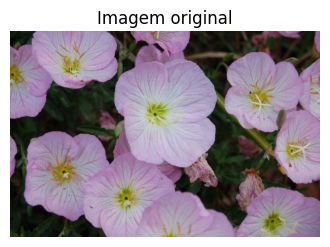

In [5]:
raw_dataset = Flowers102(
    root=DATA_DIR,
    split="train",
    transform=None,
    download=True,
)

raw_image, label = raw_dataset[SAMPLE_INDEX]
print(f"Label: {label}")
print(f"Tamanho original: {raw_image.size}")

plt.figure(figsize=(4, 4))
plt.imshow(raw_image)
plt.title("Imagem original")
plt.axis("off");

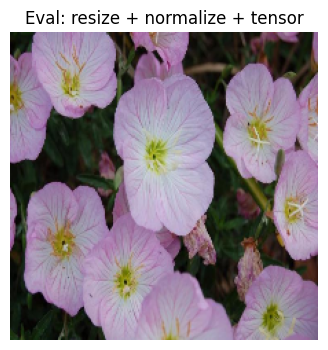

In [6]:
eval_transform = get_eval_transforms(image_size=IMAGE_SIZE)
eval_tensor = eval_transform(raw_image)

fig, ax = plt.subplots(figsize=(4, 4))
show_tensor(ax, eval_tensor, "Eval: resize + normalize + tensor")

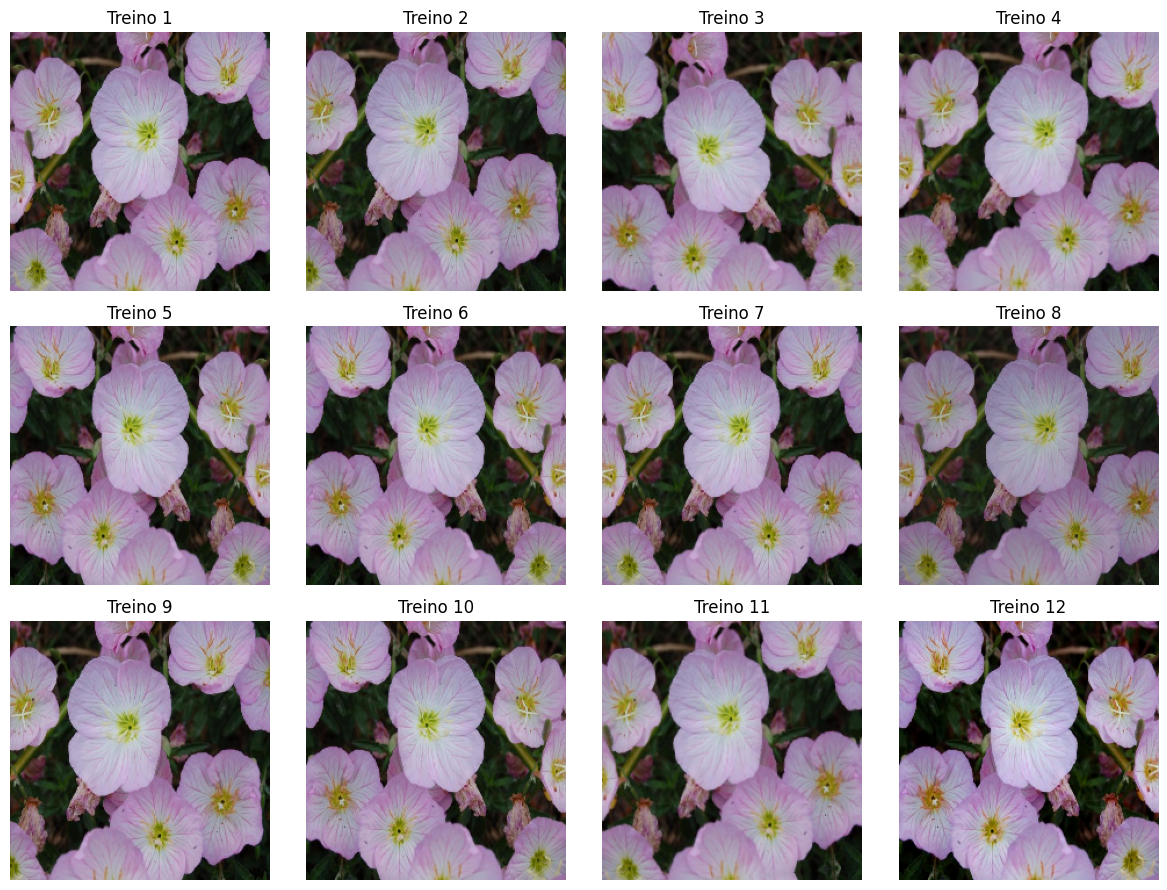

In [7]:
train_transform = get_train_transforms(
    image_size=IMAGE_SIZE,
    use_augmentation=True,
    random_erasing_p=RANDOM_ERASING_P,
)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flat, start=1):
    augmented_tensor = train_transform(raw_image)
    show_tensor(ax, augmented_tensor, f"Treino {i}")

plt.tight_layout()

A celula abaixo forca `random_erasing_p=1.0` apenas para visualizacao. Nao eh a configuracao do E4; serve para confirmar como o bloco apagado aparece.

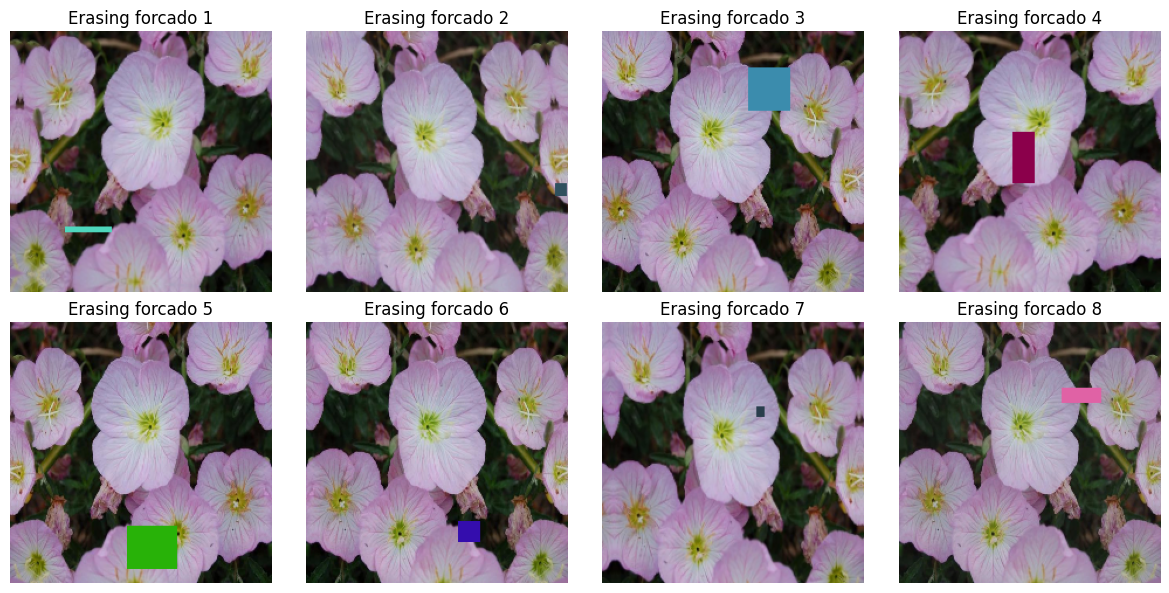

In [8]:
forced_erasing_transform = get_train_transforms(
    image_size=IMAGE_SIZE,
    use_augmentation=True,
    random_erasing_p=1.0,
)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat, start=1):
    augmented_tensor = forced_erasing_transform(raw_image)
    show_tensor(ax, augmented_tensor, f"Erasing forcado {i}")

plt.tight_layout()